# Tugas 1 - Klasifikasi Jamur dengan Naive Bayes

| Nama | NRP |
|------|-----|
| Muhammad Azka Ananta Khairon | 5054251004|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Mushroom Dataset dari UCI Machine Learning Repository.

Dataset dapat diakses melalui:
- https://www.kaggle.com/datasets/uciml/mushroom-classification

Untuk metadata / penjelasan mengenai dataset bisa mengakses link berikut:
- https://archive.ics.uci.edu/dataset/73/mushroom

Tujuan utama dari tugas ini adalah membangun dan membandingkan tiga varian Naive Bayes, yaitu Categorical NB, Bernoulli NB, dan Multinomial NB, untuk mengklasifikasikan apakah suatu jamur dapat dimakan (edible) atau beracun (poisonous).

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan untuk masing-masing varian Naive Bayes.
3. Eksperimen Model
   - Bangun model Categorical NB, Bernoulli NB, dan Multinomial NB.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil ketiga model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [ ]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.naive_bayes import CategoricalNB, BernoulliNB, MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score


In [ ]:
# Load dataset dan tampilkan beberapa baris pertama.
# Semua nilai pada dataset berupa single character yang merupakan kode singkatan dari kategori.
# Contoh: pada kolom class, e = edible dan p = poisonous.

data = pd.read_csv("/content/mushrooms.csv")
print("Jumlah baris dan kolom:", data.shape)
data.head()

Jumlah baris dan kolom: (8124, 23)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [ ]:
# Tampilkan informasi dasar dataset: jumlah baris dan kolom, tipe data, dan jumlah missing value.
# Perhatikan kolom stalk-root yang memiliki nilai '?' sebagai representasi missing value.

data.info()
data.describe()
print("Baris duplikat :",(data.duplicated().sum()))
print("Jumlah baris kosong:")
data.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

,0
class,0
cap-shape,0
cap-surface,0
cap-color,0
bruises,0
odor,0
gill-attachment,0
gill-spacing,0
gill-size,0
gill-color,0


In [ ]:
# Tampilkan jumlah nilai unik pada setiap fitur.
# Perhatikan variasi jumlah kategori antar fitur, misalnya veil-type hanya punya 1 nilai unik.

for col in data.columns:
    print(f"=== Unique values in '{col}' ===")
    print(data[col].unique())
    print(data[col].nunique())
    print()

=== Unique values in 'class' ===
['p' 'e']
2

=== Unique values in 'cap-shape' ===
['x' 'b' 's' 'f' 'k' 'c']
6

=== Unique values in 'cap-surface' ===
['s' 'y' 'f' 'g']
4

=== Unique values in 'cap-color' ===
['n' 'y' 'w' 'g' 'e' 'p' 'b' 'u' 'c' 'r']
10

=== Unique values in 'bruises' ===
['t' 'f']
2

=== Unique values in 'odor' ===
['p' 'a' 'l' 'n' 'f' 'c' 'y' 's' 'm']
9

=== Unique values in 'gill-attachment' ===
['f' 'a']
2

=== Unique values in 'gill-spacing' ===
['c' 'w']
2

=== Unique values in 'gill-size' ===
['n' 'b']
2

=== Unique values in 'gill-color' ===
['k' 'n' 'g' 'p' 'w' 'h' 'u' 'e' 'b' 'r' 'y' 'o']
12

=== Unique values in 'stalk-shape' ===
['e' 't']
2

=== Unique values in 'stalk-root' ===
['e' 'c' 'b' 'r' '?']
5

=== Unique values in 'stalk-surface-above-ring' ===
['s' 'f' 'k' 'y']
4

=== Unique values in 'stalk-surface-below-ring' ===
['s' 'f' 'y' 'k']
4

=== Unique values in 'stalk-color-above-ring' ===
['w' 'g' 'p' 'n' 'b' 'e' 'o' 'c' 'y']
9

=== Unique values in 

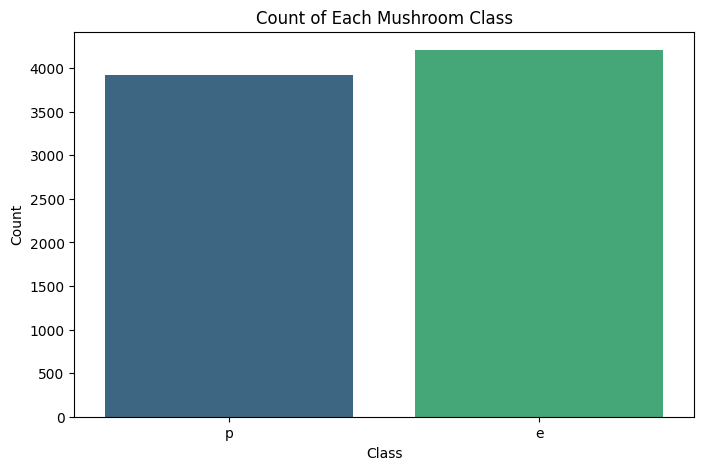

In [ ]:
# Tampilkan distribusi kelas target (class) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.

plt.figure(figsize=(8, 5))
sns.countplot(x='class', hue='class', data=data, palette='viridis', legend=False)
plt.title('Count of Each Mushroom Class')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

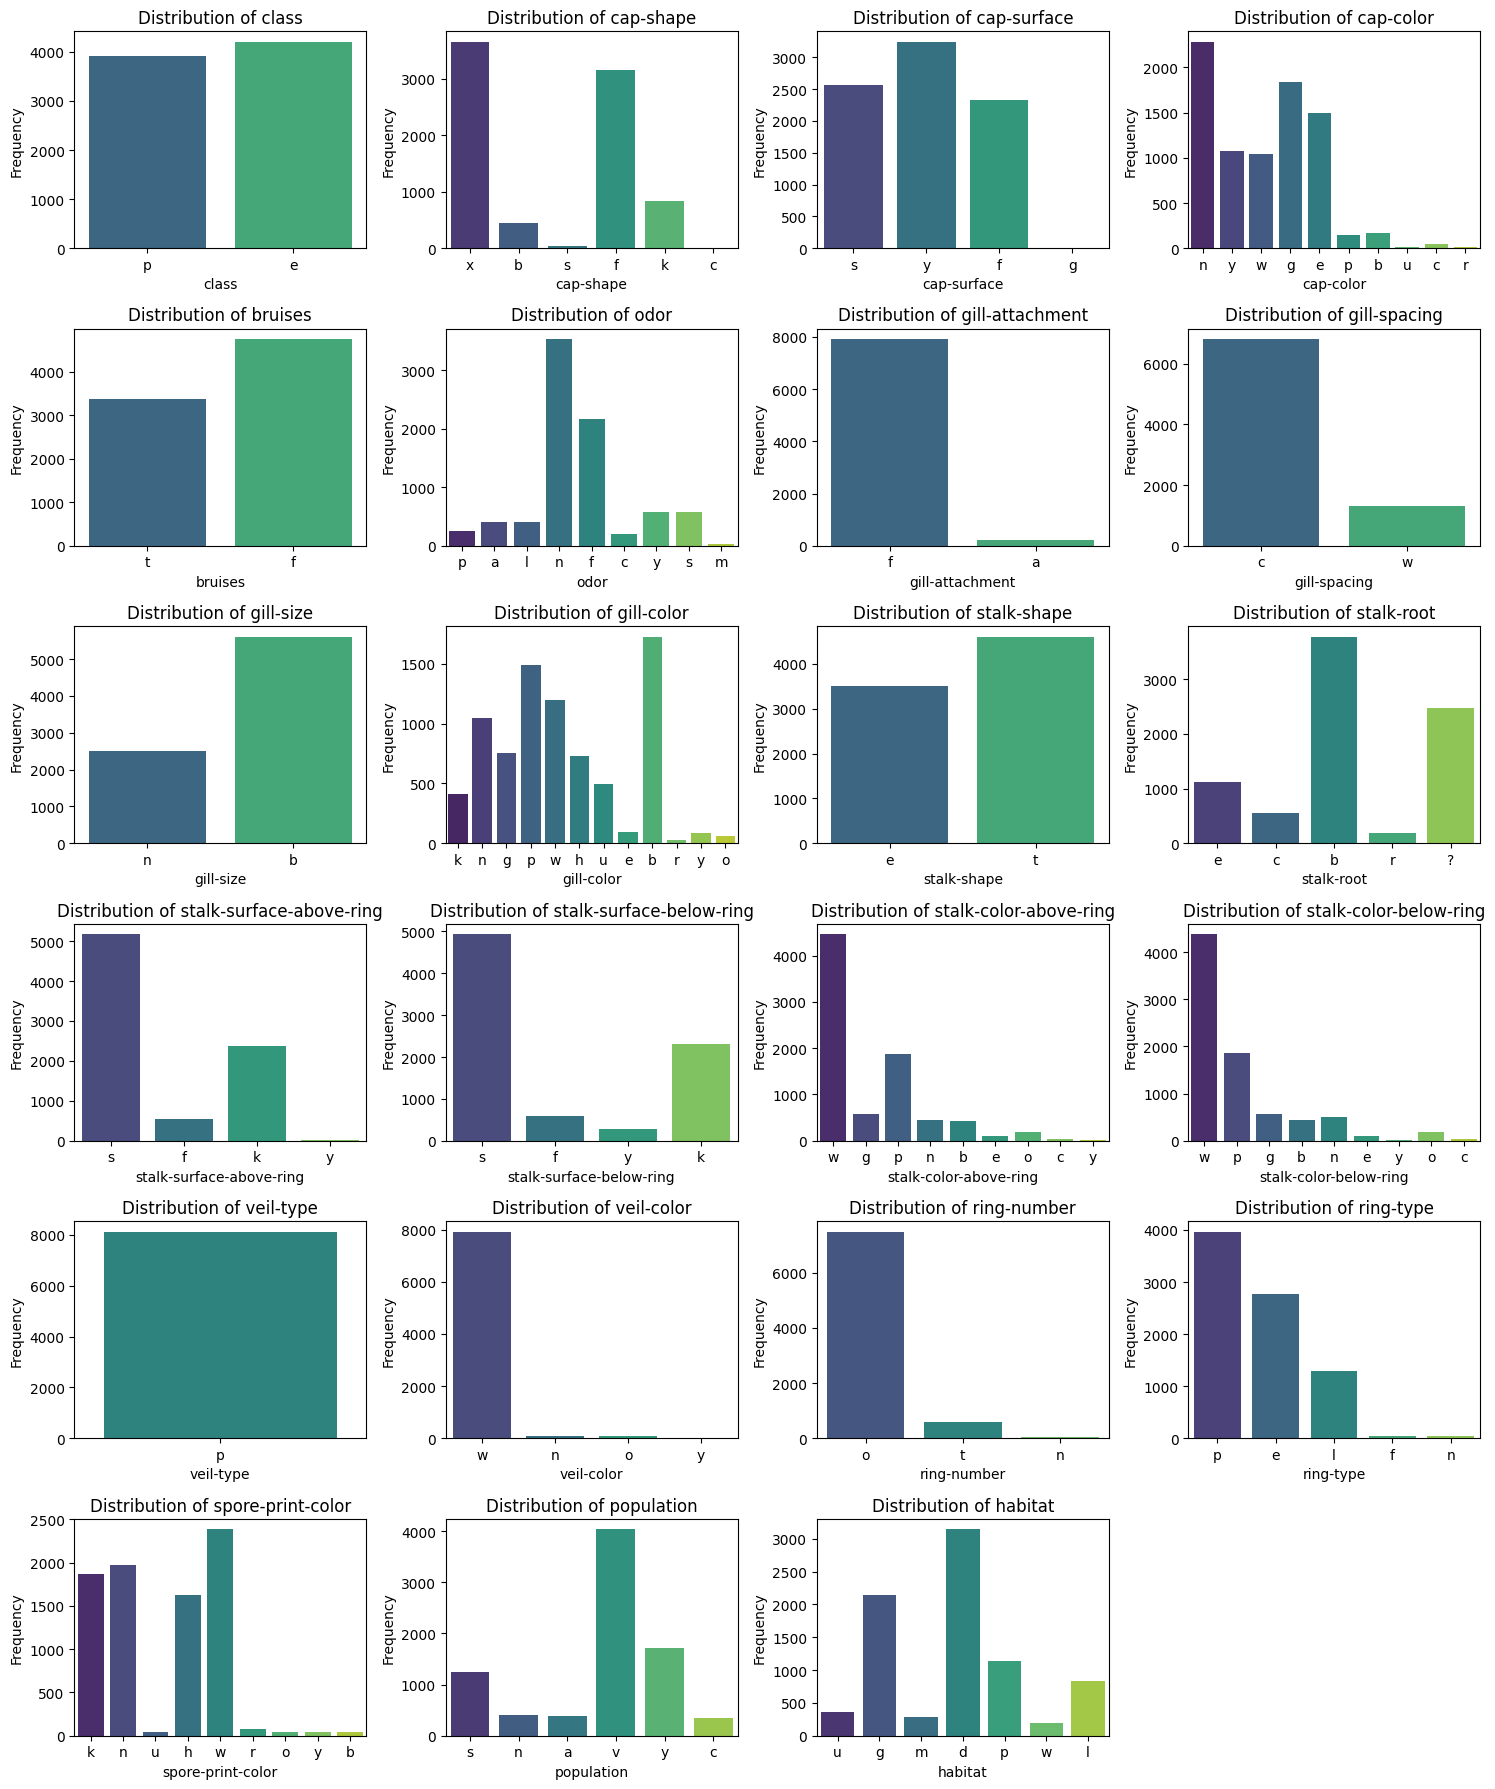

In [ ]:
features = [col for col in data.columns if col != "Class"]

plt.figure(figsize=(15, 18))
for i, col in enumerate(features):
  plt.subplot(6, 4, i + 1)
  sns.countplot(x=col, hue=col, data=data, palette='viridis', legend=False)
  plt.title(f'Distribution of {col}')
  plt.xlabel(col)
  plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# 2. Preprocessing

Karena semua fitur bertipe kategorikal, setiap varian Naive Bayes membutuhkan representasi data yang berbeda:

| Model | Representasi yang dibutuhkan | Preprocessing |
|---|---|---|
| Categorical NB | Integer per kategori | OrdinalEncoder |
| Bernoulli NB | Binary 0/1 per kategori | LabelBinarizer / OneHotEncoder |
| Multinomial NB | Count / frekuensi non-negatif | OneHotEncoder |

In [ ]:
# Tangani missing value pada kolom stalk-root (nilai '?').
# Pilih strategi yang sesuai: drop baris, ganti dengan modus, atau jadikan kategori tersendiri.

print("jumlah missing values pada stalk-root:", (data['stalk-root'] == '?').sum())

jumlah missing values pada stalk-root: 2480


In [ ]:
# Periksa apakah ada fitur yang hanya memiliki satu nilai unik.
# Fitur seperti itu tidak memberikan informasi apapun dan sebaiknya di-drop.

data_clean = data.drop(columns=["veil-type"])

In [ ]:
# Pisahkan fitur (X) dan target (y).
# Encode target: e = 0 (edible), p = 1 (poisonous).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.

X = data_clean.drop(columns=['class'])
y = data_clean['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

label_mapping = {'e': 0, 'p': 1}
y_train = y_train.map(label_mapping)
y_test = y_test.map(label_mapping)

print("Ukuran data train:", X_train.shape)

Ukuran data train: (6499, 21)


In [ ]:
# Preprocessing untuk Categorical NB:
# Gunakan OrdinalEncoder untuk mengubah setiap kategori menjadi integer.
# Contoh: cap-shape b=0, c=1, f=2, k=3, s=4, x=5
# Fit hanya pada train set, transform pada train set dan test set.

ordinal_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

X_train_ord = ordinal_encoder.fit_transform(X_train)
X_test_ord = ordinal_encoder.transform(X_test)

In [ ]:
X_train_ord_df = pd.DataFrame(X_train_ord, columns=X_train.columns)
X_train_ord_df.head()

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,2.0,3.0,9.0,0.0,2.0,1.0,0.0,0.0,2.0,0.0,...,1.0,1.0,6.0,0.0,2.0,1.0,2.0,1.0,5.0,1.0
1,5.0,2.0,5.0,1.0,5.0,1.0,0.0,0.0,1.0,0.0,...,2.0,2.0,2.0,7.0,2.0,2.0,0.0,7.0,1.0,6.0
2,0.0,2.0,3.0,0.0,5.0,1.0,1.0,0.0,10.0,0.0,...,1.0,2.0,7.0,7.0,2.0,2.0,4.0,7.0,3.0,1.0
3,2.0,2.0,4.0,0.0,7.0,1.0,0.0,1.0,0.0,1.0,...,1.0,1.0,6.0,7.0,2.0,1.0,0.0,7.0,4.0,0.0
4,3.0,3.0,4.0,0.0,2.0,1.0,0.0,1.0,0.0,1.0,...,2.0,1.0,6.0,6.0,2.0,1.0,0.0,7.0,4.0,4.0


In [ ]:
for col, categories in zip(X_train.columns, ordinal_encoder.categories_):
    print(f"Kolom {col}: {list(enumerate(categories))[:5]}")

Kolom cap-shape: [(0, 'b'), (1, 'c'), (2, 'f'), (3, 'k'), (4, 's')]
Kolom cap-surface: [(0, 'f'), (1, 'g'), (2, 's'), (3, 'y')]
Kolom cap-color: [(0, 'b'), (1, 'c'), (2, 'e'), (3, 'g'), (4, 'n')]
Kolom bruises: [(0, 'f'), (1, 't')]
Kolom odor: [(0, 'a'), (1, 'c'), (2, 'f'), (3, 'l'), (4, 'm')]
Kolom gill-attachment: [(0, 'a'), (1, 'f')]
Kolom gill-spacing: [(0, 'c'), (1, 'w')]
Kolom gill-size: [(0, 'b'), (1, 'n')]
Kolom gill-color: [(0, 'b'), (1, 'e'), (2, 'g'), (3, 'h'), (4, 'k')]
Kolom stalk-shape: [(0, 'e'), (1, 't')]
Kolom stalk-root: [(0, '?'), (1, 'b'), (2, 'c'), (3, 'e'), (4, 'r')]
Kolom stalk-surface-above-ring: [(0, 'f'), (1, 'k'), (2, 's'), (3, 'y')]
Kolom stalk-surface-below-ring: [(0, 'f'), (1, 'k'), (2, 's'), (3, 'y')]
Kolom stalk-color-above-ring: [(0, 'b'), (1, 'c'), (2, 'e'), (3, 'g'), (4, 'n')]
Kolom stalk-color-below-ring: [(0, 'b'), (1, 'c'), (2, 'e'), (3, 'g'), (4, 'n')]
Kolom veil-color: [(0, 'n'), (1, 'o'), (2, 'w'), (3, 'y')]
Kolom ring-number: [(0, 'n'), (1, 'o'

In [ ]:
# Preprocessing untuk Bernoulli NB dan Multinomial NB:
# Gunakan OneHotEncoder untuk mengubah setiap kategori menjadi representasi binary.
# Hasilnya berupa matriks sparse dengan nilai 0 dan 1.
# Fit hanya pada train set, transform pada train set dan test set.

ohe_encoder = OneHotEncoder(handle_unknown='ignore')

X_train_ohe = ohe_encoder.fit_transform(X_train)
X_test_ohe = ohe_encoder.transform(X_test)

In [ ]:
ohe_feature_names = ohe_encoder.get_feature_names_out(X_train.columns)
X_train_ohe_df = pd.DataFrame(X_train_ohe.toarray(), columns=ohe_feature_names)
X_train_ohe_df.head()

,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,cap-surface_s,cap-surface_y,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


# 3. Eksperimen Model

## 3.1 Categorical Naive Bayes

CategoricalNB adalah varian yang paling sesuai untuk dataset ini karena semua fitur memang bertipe kategorikal. Model menghitung P(fitur=kategori | kelas) secara langsung untuk setiap kategori pada setiap fitur.

In [ ]:
# Inisialisasi dan latih model CategoricalNB menggunakan train set hasil OrdinalEncoder.

cnb = CategoricalNB()
cnb.fit(X_train_ord, y_train)

CategoricalNB()

In [ ]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.

y_pred_cnb = cnb.predict(X_test_ord)
y_prob_cnb = cnb.predict_proba(X_test_ord)[:, 1]

## 3.2 Bernoulli Naive Bayes

BernoulliNB bekerja pada representasi binary. Dengan OneHotEncoder, setiap kategori menjadi kolom tersendiri bernilai 0 atau 1, sehingga model memperlakukan setiap kategori sebagai fitur binary ada/tidak ada.

In [ ]:
# Inisialisasi dan latih model BernoulliNB menggunakan train set hasil OneHotEncoder.

bnb = BernoulliNB()
bnb.fit(X_train_ohe, y_train)

BernoulliNB()

In [ ]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.

y_pred_bnb = bnb.predict(X_test_ohe)
y_prob_bnb = bnb.predict_proba(X_test_ohe)[:, 1]

## 3.3 Multinomial Naive Bayes

MultinomialNB membutuhkan input non-negatif dan menginterpretasikannya sebagai frekuensi. Dengan OneHotEncoder yang menghasilkan nilai 0 dan 1, model dapat menerimanya sebagai counts meskipun secara semantik tiap nilai hanya menandakan ada/tidak ada kategori.

In [ ]:
# Inisialisasi dan latih model MultinomialNB menggunakan train set hasil OneHotEncoder.

mnb = MultinomialNB()
mnb.fit(X_train_ohe, y_train)

MultinomialNB()

In [ ]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.

y_pred_mnb = mnb.predict(X_test_ohe)
y_prob_mnb = mnb.predict_proba(X_test_ohe)[:, 1]

# 4. Evaluasi Model

In [ ]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.

metrics_data = {
    'Model': ['Categorical NB', 'Bernoulli NB', 'Multinomial NB'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_cnb),
        accuracy_score(y_test, y_pred_bnb),
        accuracy_score(y_test, y_pred_mnb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_cnb, pos_label=1),
        precision_score(y_test, y_pred_bnb, pos_label=1),
        precision_score(y_test, y_pred_mnb, pos_label=1)
    ],
    'Recall': [
        recall_score(y_test, y_pred_cnb, pos_label=1),
        recall_score(y_test, y_pred_bnb, pos_label=1),
        recall_score(y_test, y_pred_mnb, pos_label=1)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_cnb, pos_label=1),
        f1_score(y_test, y_pred_bnb, pos_label=1),
        f1_score(y_test, y_pred_mnb, pos_label=1)
    ]
}

df_comparison = pd.DataFrame(metrics_data)
df_comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Categorical NB,0.945846,0.990127,0.896552,0.941019
1,Bernoulli NB,0.932923,0.981429,0.877395,0.926500
2,Multinomial NB,0.945846,0.990127,0.896552,0.941019


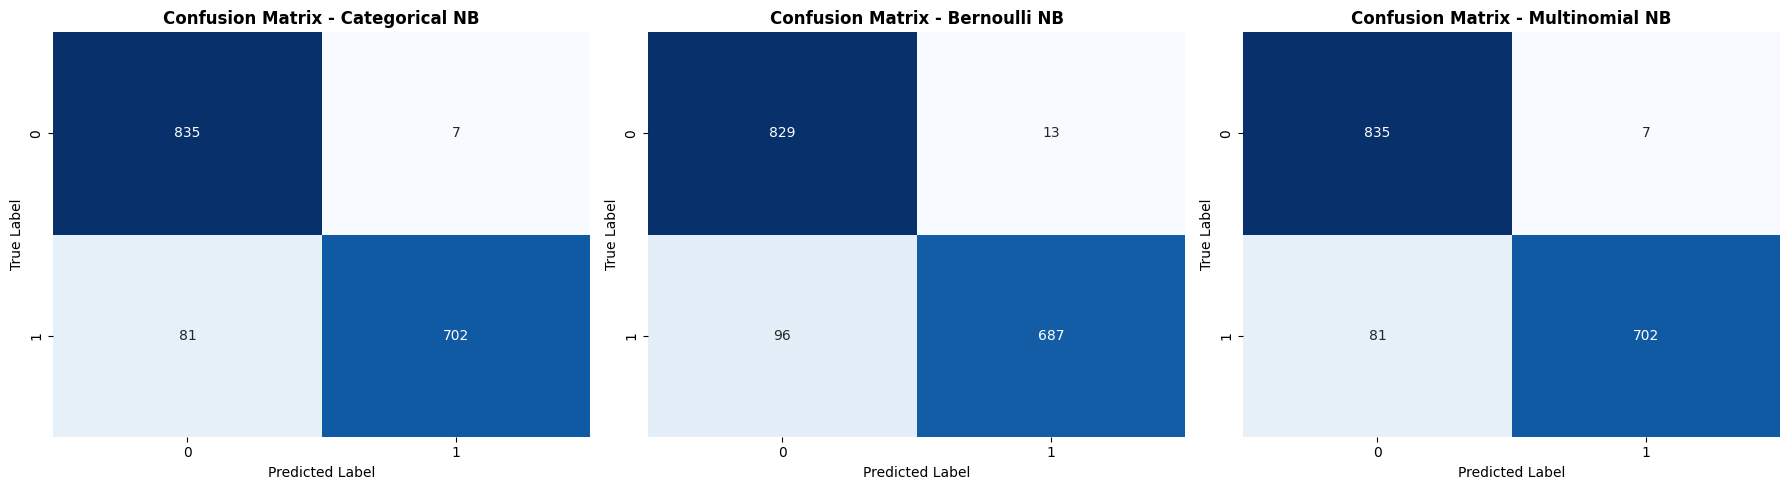

In [ ]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
# Susun ketiganya dalam satu baris subplot.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    ('Categorical NB', y_pred_cnb, axes[0]),
    ('Bernoulli NB', y_pred_bnb, axes[1]),
    ('Multinomial NB', y_pred_mnb, axes[2])
]

for title, y_pred, ax in models:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(f'Confusion Matrix - {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.show()

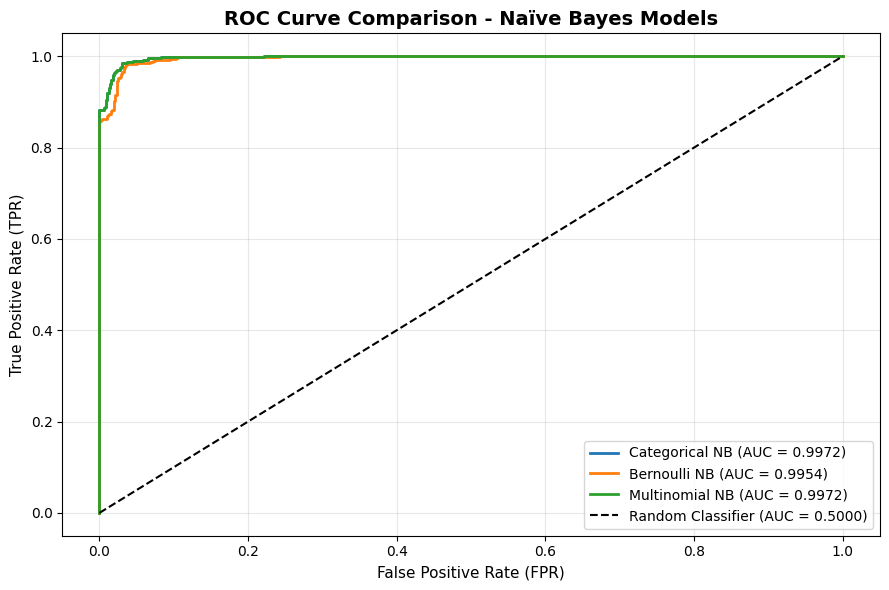

In [ ]:
# Tampilkan ROC Curve ketiga model dalam satu plot beserta nilai AUC masing-masing.

fpr_cnb, tpr_cnb, _ = roc_curve(y_test, y_prob_cnb)
auc_cnb = roc_auc_score(y_test, y_prob_cnb)

fpr_bnb, tpr_bnb, _ = roc_curve(y_test, y_prob_bnb)
auc_bnb = roc_auc_score(y_test, y_prob_bnb)

fpr_mnb, tpr_mnb, _ = roc_curve(y_test, y_prob_mnb)
auc_mnb = roc_auc_score(y_test, y_prob_mnb)

plt.figure(figsize=(9, 6))

plt.plot(fpr_cnb, tpr_cnb, label=f'Categorical NB (AUC = {auc_cnb:.4f})', linewidth=2)
plt.plot(fpr_bnb, tpr_bnb, label=f'Bernoulli NB (AUC = {auc_bnb:.4f})', linewidth=2)
plt.plot(fpr_mnb, tpr_mnb, label=f'Multinomial NB (AUC = {auc_mnb:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5000)')

plt.title('ROC Curve Comparison - Naïve Bayes Models', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate (FPR)', fontsize=11)
plt.ylabel('True Positive Rate (TPR)', fontsize=11)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Analisis

#### Berdasarkan hasil eksperimen klasifikasi pada dataset Mushroom UCI, ketiga varian algoritma Naïve Bayes menunjukkan performa yang sangat kuat dalam memisahkan kelas jamur edible dan poisonous. Hal ini dibuktikan oleh nilai AUC dari ketiga model yang semuanya berada di atas 0.99
### Meskipun ketiga model mampu mencapai akurasi di atas 93%, terdapat perbedaan karakteristik performa dari masing-masing varian:

###1. Categorical NB & Multinomial NB mencatatkan akurasi tertinggi sebesar 94.58% dengan nilai AUC 0.9972. Dari total 1.625 data uji, keduanya hanya menghasilkan 88 kesalahan prediksi (835 True Negative, 702 True Positive, 7 False Positive, dan 81 False Negative). Kesamaan hasil ini terjadi karena data kategorik yang telah diproses menggunakan One-Hot Encoding menghasilkan variabel biner yang kalkulasi matematis likelihood-nya pada Multinomial NB menjadi ekuivalen dengan estimasi distribusi pada Categorical NB.
###2. Bernoulli NB memiliki performa yang lebih rendah dengan akurasi 93.29%, nilai AUC 0.9954, dan total 109 kesalahan prediksi. Penurunan performa ini disebabkan oleh asumsi dasar Bernoulli NB yang hanya memodelkan keberadaan dari suatu fitur biner secara independen, sehingga kurang optimal dalam menangkap interaksi multi-kategori yang ada pada fitur fisik jamur.




# 6. Kesimpulan dan Saran

#### Dari sudut pandang  medis, kesalahan  False Negative (jamur beracun yang salah diprediksi sebagai jamur edible) memiliki dampak yang sangat fatal. Meskipun Categorical NB dan Multinomial NB berhasil menekan nilai False Negative hingga 81 sampel (lebih baik dibanding Bernoulli NB yang mencapai 96 sampel), jumlah kesalahan tersebut masih tergolong berisiko tinggi untuk penerapan dunia nyata.